# Cluster Analysis – Heart Failure Prediction Dataset
*Cluster analysis for the Heart Failure Prediction Dataset*  

---
## Table of Contents

<a id='imports'></a>
## Reproducibility & Imports  
---

In [1]:
import os, sys, umap, joblib, numpy as np, pandas as pd

sys.path.append(os.path.abspath(os.path.join('..')))

from plotly.io import show
from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering
from scripts.dim_red.plots import plot_3d
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scripts.clustering.utils import *

SEED = 42
TARGET_COL = "DEATH_EVENT"
OUTPUT_DIR = "../outputs/clustering"
os.makedirs(OUTPUT_DIR, exist_ok=True)

### Data Loading

In [2]:
df_pca = joblib.load('../outputs/dim_red/df_pca.pkl')
df_tsne = joblib.load('../outputs/dim_red/df_tsne.pkl')
df_umap = joblib.load('../outputs/dim_red/df_umap.pkl')
df_mix = joblib.load('../outputs/dim_red/df_mix.pkl')
df_umap_supervised = joblib.load('../outputs/dim_red/df_umap_supervised.pkl')
df_umap_semisupervised = joblib.load('../outputs/dim_red/df_umap_semisupervised.pkl')
df_umap_xgb = joblib.load('../outputs/dim_red/df_umap_xgb.pkl')
df_preprocessed = joblib.load('../outputs/eda/df_preprocessed_balanced.pkl')

### Split features

In [24]:
X_pca  = df_pca.iloc[:, :-1]
X_tsne = df_tsne.iloc[:, :-1]
X_umap = df_umap.iloc[:, :-1]
X_mix  = df_mix.iloc[:, :-1]

X_umap_supervised    = df_umap_supervised.iloc[:, :-1]
X_umap_semisupervised = df_umap_semisupervised.iloc[:, :-1]
X_umap_xgb           = df_umap_xgb.iloc[:, :-1]

X_pre  = df_preprocessed.iloc[:, :-1]
y      = df_preprocessed.iloc[:, -1]

### Drop weak features

In [25]:
cols_to_drop = ['high_blood_pressure', 'platelets', 'sex', 'creatinine_phosphokinase', 'anaemia', 'smoking', 'diabetes']
X_pre = X_pre.drop(columns=cols_to_drop)

X_pre.shape

(308, 5)

## Clustering on Embeddings – Hyper‑Parameter Search
---

In [ ]:
# === Unsupervised embeddings ===
embeddings_unsupervised = {
    "pca":  X_pca,
    "tsne": X_tsne,
    "umap": X_umap,
    "mix":  X_mix,
}

# === Supervised / label-informed embeddings ===
embeddings_supervised = {
    "umap_supervised":     X_umap_supervised,
    "umap_semisupervised": X_umap_semisupervised,
    "umap_xgb":            X_umap_xgb,
}

embeddings_all = {
    **embeddings_unsupervised,
    **embeddings_supervised,
}

rows: list[dict] = []


=== Embedding: PCA ===


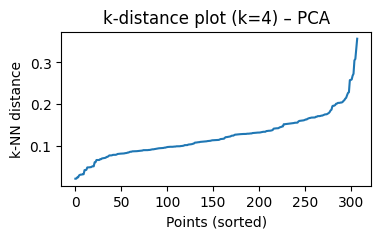

[DBSCAN] best params: {'eps': 0.2, 'min_samples': 5}
[KMeans] best params: {'n_clusters': 4, 'n_init': 20}
[Agglomerative] best params: {'n_clusters': 7, 'linkage': 'ward', 'metric': 'euclidean'}

=== Embedding: TSNE ===


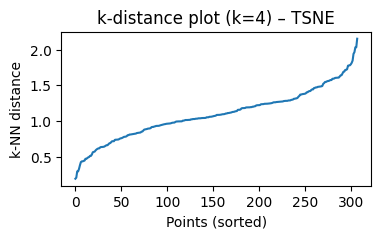

[DBSCAN] best params: {'eps': 1.2, 'min_samples': 3}
[KMeans] best params: {'n_clusters': 5, 'n_init': 10}
[Agglomerative] best params: {'n_clusters': 5, 'linkage': 'complete', 'metric': 'euclidean'}

=== Embedding: UMAP ===


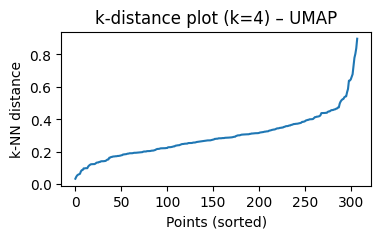

[DBSCAN] best params: {'eps': 0.5, 'min_samples': 3}
[KMeans] best params: {'n_clusters': 5, 'n_init': 10}
[Agglomerative] best params: {'n_clusters': 7, 'linkage': 'complete', 'metric': 'euclidean'}

=== Embedding: MIX ===


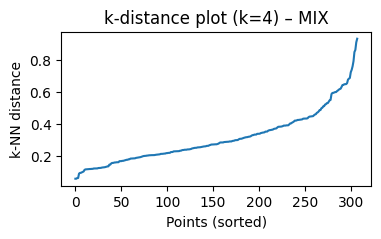

[DBSCAN] best params: {'eps': 0.5, 'min_samples': 10}
[KMeans] best params: {'n_clusters': 2, 'n_init': 10}
[Agglomerative] best params: {'n_clusters': 3, 'linkage': 'ward', 'metric': 'euclidean'}

=== Embedding: UMAP_SUPERVISED ===


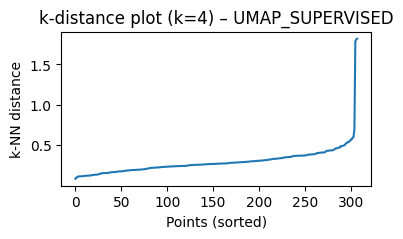

[DBSCAN] best params: {'eps': 0.8, 'min_samples': 3}
[KMeans] best params: {'n_clusters': 2, 'n_init': 10}
[Agglomerative] best params: {'n_clusters': 2, 'linkage': 'ward', 'metric': 'euclidean'}

=== Embedding: UMAP_SEMISUPERVISED ===


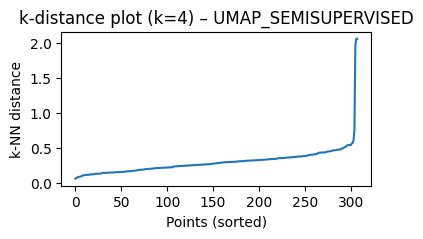

[DBSCAN] best params: {'eps': 0.8, 'min_samples': 3}
[KMeans] best params: {'n_clusters': 2, 'n_init': 10}
[Agglomerative] best params: {'n_clusters': 2, 'linkage': 'ward', 'metric': 'euclidean'}

=== Embedding: UMAP_XGB ===


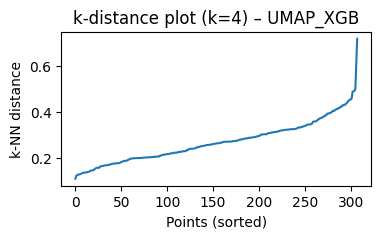

[DBSCAN] best params: {'eps': 0.5, 'min_samples': 3}
[KMeans] best params: {'n_clusters': 3, 'n_init': 20}
[Agglomerative] best params: {'n_clusters': 3, 'linkage': 'ward', 'metric': 'euclidean'}


In [5]:
dbscan_best = {}
kmeans_best = {}
agglom_best = {}

for name, X in embeddings_all.items():
    print(f"\n=== Embedding: {name.upper()} ===")
    
    # --- 1) DBSCAN ---
    kd = k_distance_plot(X=X, k=4)
    plt.figure(figsize=(4, 2))
    plt.plot(kd)
    plt.title(f"k-distance plot (k=4) – {name.upper()}")
    plt.xlabel("Points (sorted)")
    plt.ylabel("k-NN distance")
    plt.show()
    
    db_best = gridsearch_dbscan(X=X)
    dbscan_best[name] = db_best
    print("[DBSCAN] best params:", db_best["params"])
    
    # --- 2) KMeans ---
    km_best = gridsearch_kmeans_params(X, ks=range(2, 8), n_inits=(10, 20),)
    kmeans_best[name] = km_best
    km_params  = km_best.get("params", km_best)
    km_metrics = km_best.get("metrics", None)
    print("[KMeans] best params:", km_params)
    
    # --- 3) Agglomerative ---
    ag_best = gridsearch_agglomerative_params(
        X,
        ks=range(2, 8),
        linkages=("ward", "complete", "average"),
        metrics=("euclidean", "manhattan", "cosine"),
    )
    agglom_best[name] = ag_best
    ag_params  = ag_best.get("params", ag_best)
    ag_metrics = ag_best.get("metrics", None)
    print("[Agglomerative] best params:", ag_params)


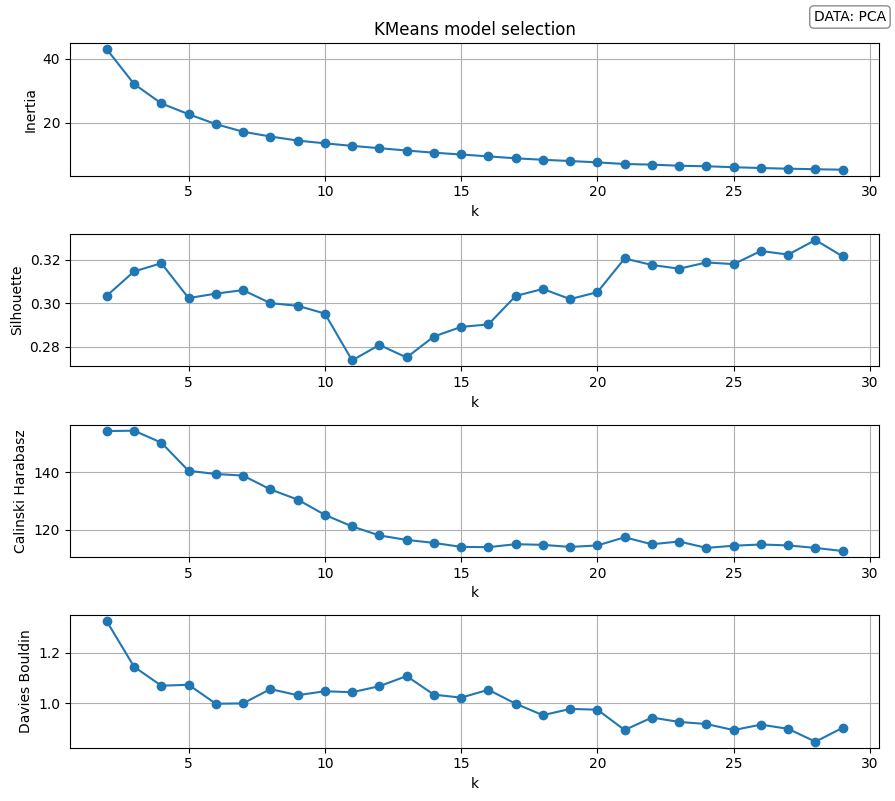

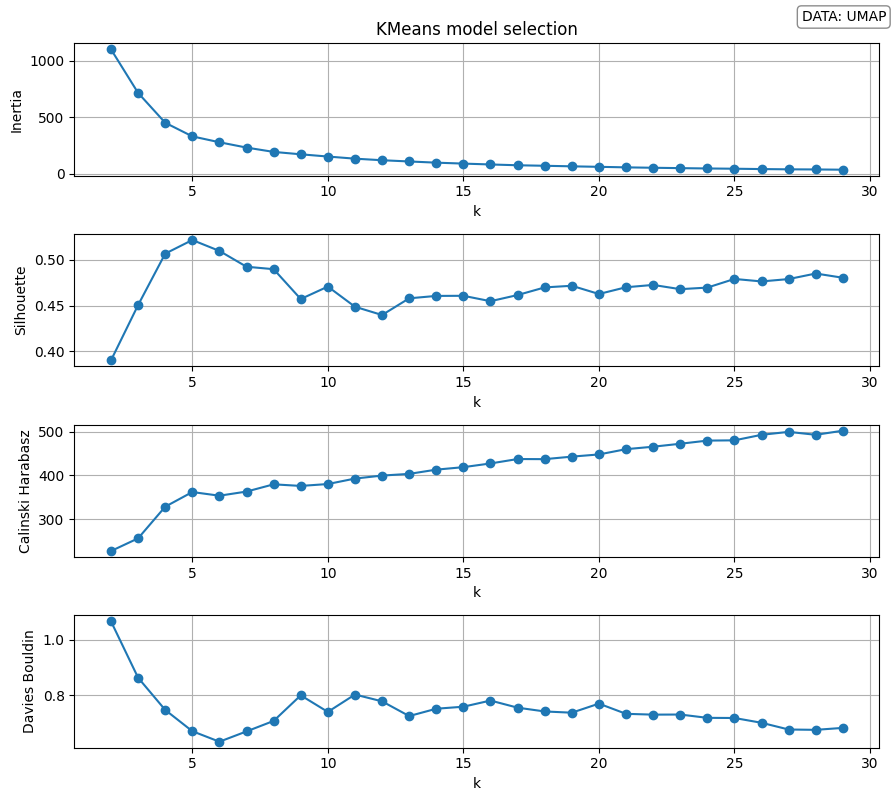

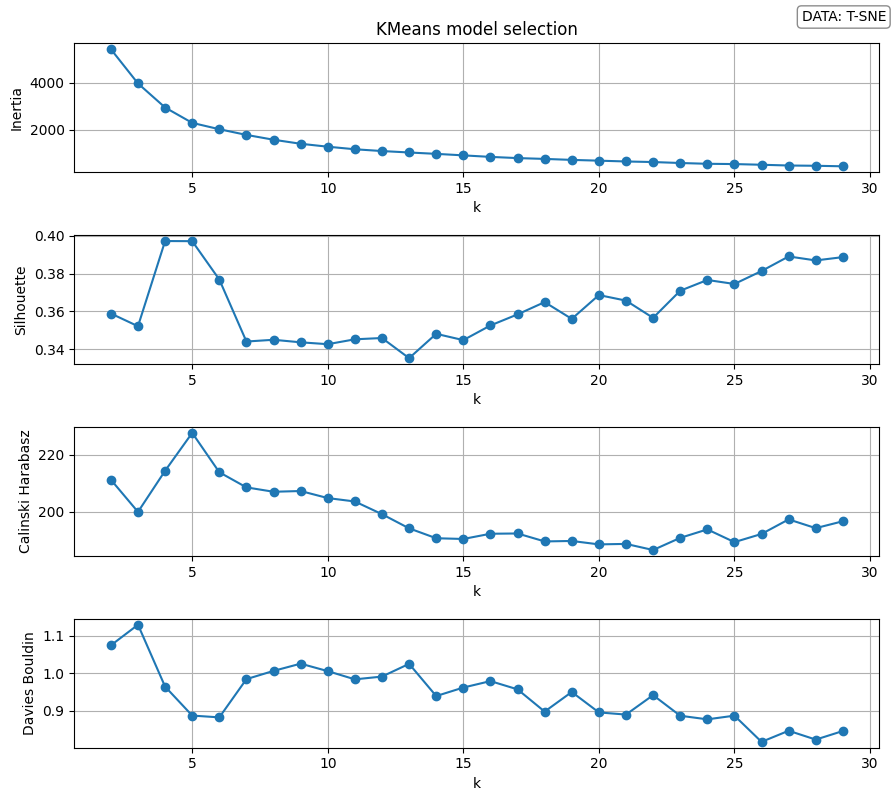

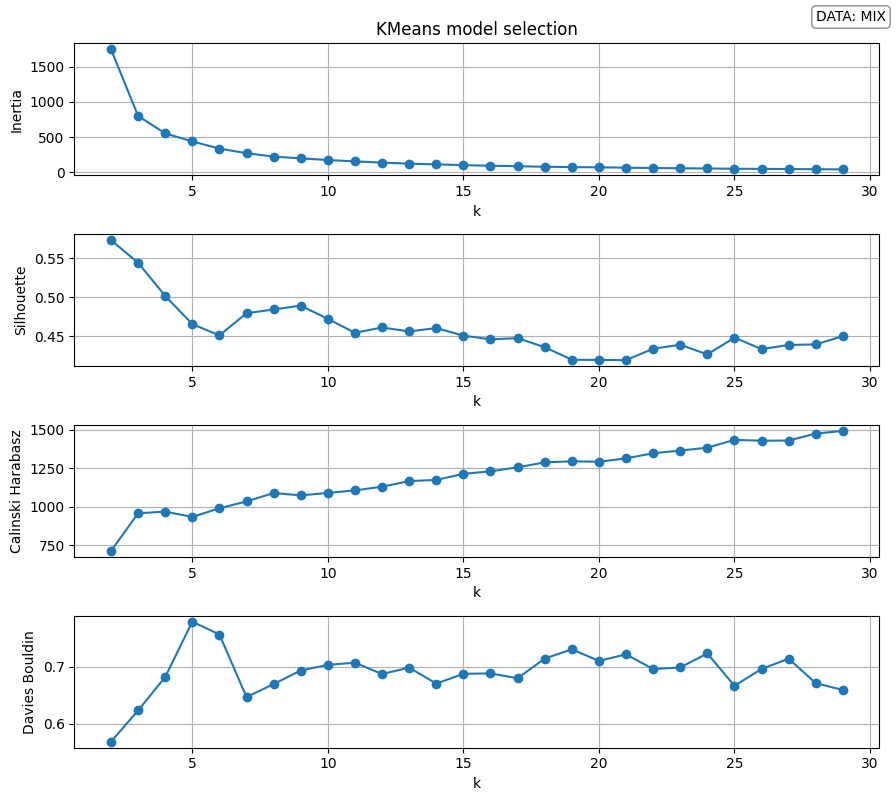


KMeans on PCA
{'inertia': 29, 'silhouette': 28, 'calinski_harabasz': 3, 'davies_bouldin': 28}

KMeans on UMAP
{'inertia': 29, 'silhouette': 5, 'calinski_harabasz': 29, 'davies_bouldin': 6}

KMeans on T-SNE
{'inertia': 29, 'silhouette': 4, 'calinski_harabasz': 5, 'davies_bouldin': 26}

KMeans on MIX
{'inertia': 29, 'silhouette': 2, 'calinski_harabasz': 29, 'davies_bouldin': 2}


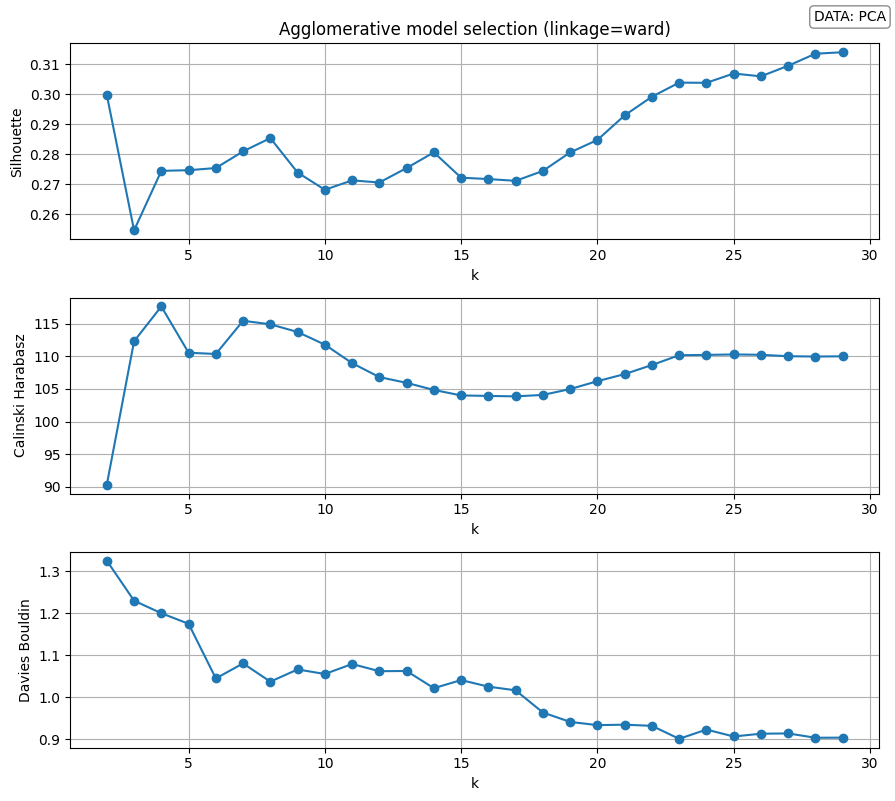

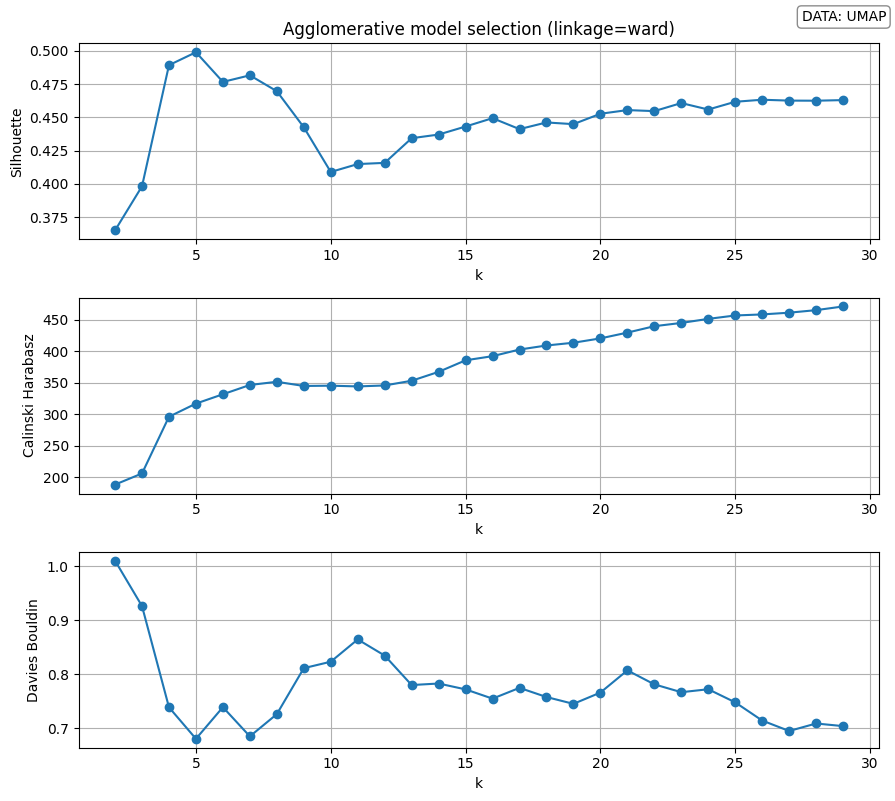

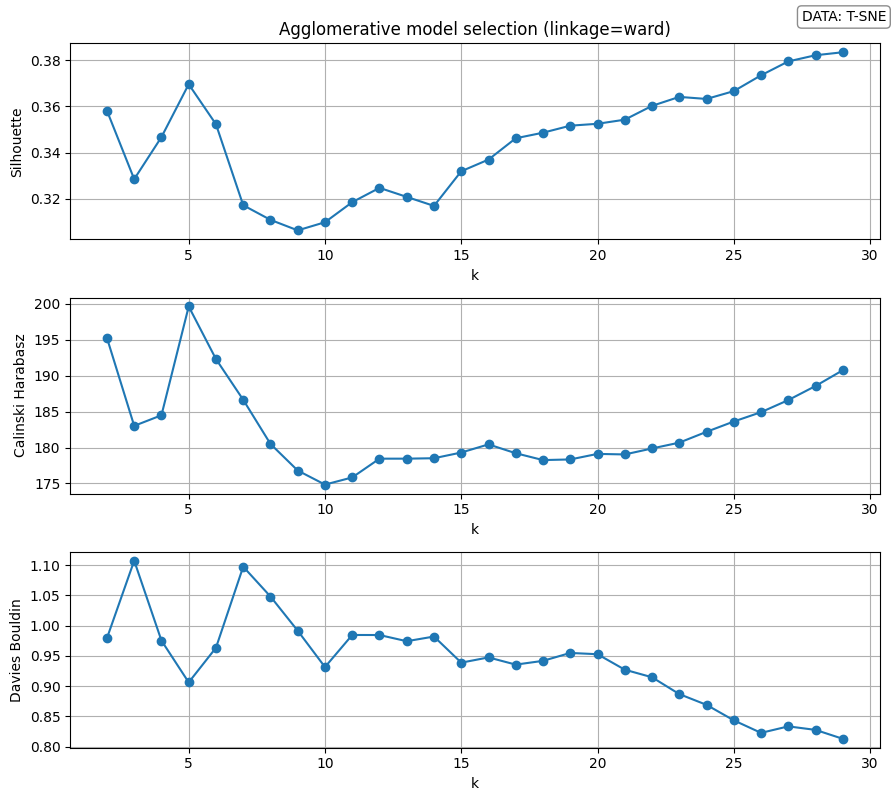

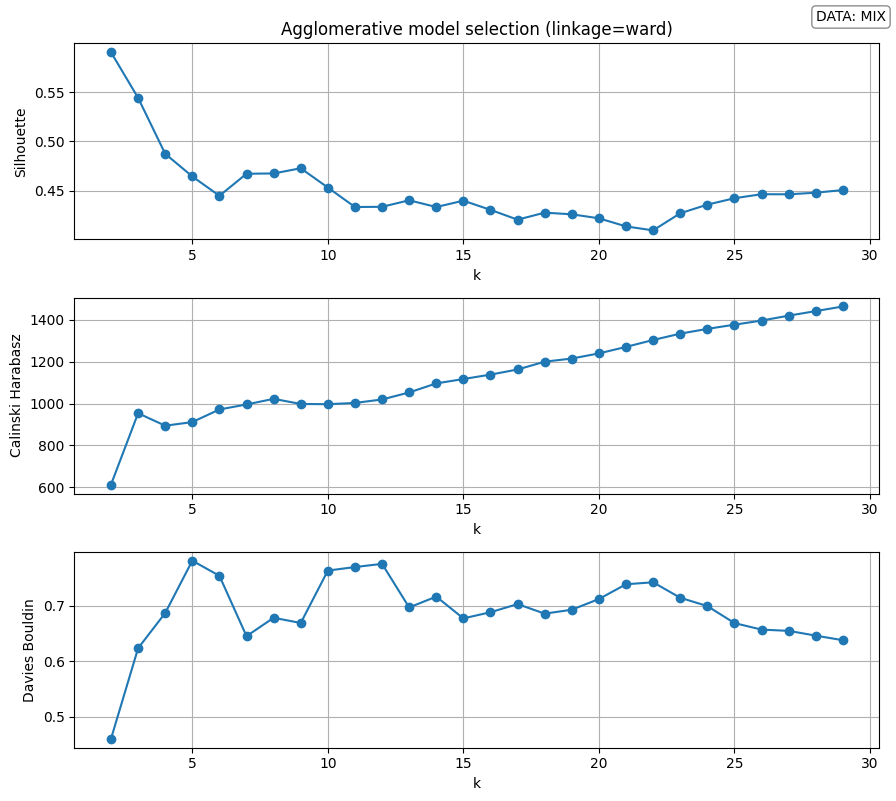


Agglomerative on PCA
{'silhouette': 29, 'calinski_harabasz': 4, 'davies_bouldin': 23}

Agglomerative on UMAP
{'silhouette': 5, 'calinski_harabasz': 29, 'davies_bouldin': 5}

Agglomerative on T-SNE
{'silhouette': 29, 'calinski_harabasz': 5, 'davies_bouldin': 29}

Agglomerative on MIX
{'silhouette': 2, 'calinski_harabasz': 29, 'davies_bouldin': 2}


In [6]:
# KMEANS
kmeans_results = {
    'pca':  select_k_kmeans(X_pca,  k_range=range(2, 30), n_init=50, data_name="PCA"),
    'umap': select_k_kmeans(X_umap, k_range=range(2, 30), n_init=50, data_name="UMAP"),
    't-SNE':select_k_kmeans(X_tsne, k_range=range(2, 30), n_init=50, data_name="t-SNE"),
    'MIX':  select_k_kmeans(X_mix,  k_range=range(2, 30), n_init=50, data_name="MIX"),
}

for name, res in kmeans_results.items():
    print(f"\nKMeans on {name.upper()}")
    print(res.best_by_metric)
    
# AGGLOMERATIVE
agg_results = {
    'pca':  select_k_agglomerative(X_pca,  k_range=range(2, 30), data_name="PCA"),
    'umap': select_k_agglomerative(X_umap, k_range=range(2, 30), data_name="UMAP"),
    't-SNE':select_k_agglomerative(X_tsne, k_range=range(2, 30), data_name="t-SNE"),
    'MIX':  select_k_agglomerative(X_mix,  k_range=range(2, 30), data_name="MIX"),
}

for name, res in agg_results.items():
    print(f"\nAgglomerative on {name.upper()}")
    print(res.best_by_metric)

## Leaderboards – Unsupervised vs Supervised Embeddings
---

### Unsupervised Embeddings

In [7]:
board_unsupervised = build_global_leaderboard(embeddings_unsupervised)
ordered_unsupervised = rank_leaderboard(board_unsupervised)

rows_unsup = []
for i, r in enumerate(ordered_unsupervised, 1):
    m = r["metrics"]
    rows_unsup.append({
        "Rank": i,
        "Embedding": r["emb"].upper(),
        "Algorithm": r["algo"].upper(),
        "Params": str(r["params"]),
        "Clusters": m.get("n_clusters"),
        "Silhouette": round(m.get("silhouette"), 4),
        "Calinski-Harabasz": round(m.get("calinski_harabasz"), 2),
        "Davies-Bouldin": round(m.get("davies_bouldin"), 4),
    })

df_leader_unsup = pd.DataFrame(rows_unsup)
df_leader_unsup.style    .background_gradient(subset=["Silhouette"], cmap="Greens")    .background_gradient(subset=["Calinski-Harabasz"], cmap="Blues")    .background_gradient(subset=["Davies-Bouldin"], cmap="Reds_r")    .format({"Silhouette": "{:.4f}", "Calinski-Harabasz": "{:.2f}", "Davies-Bouldin": "{:.4f}"})


,Rank,Embedding,Algorithm,Params,Clusters,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,1,MIX,KMEANS,"{'n_clusters': 2, 'n_init': 10}",2,0.5735,711.62,0.5681
1,2,MIX,AGGLOMERATIVE,"{'n_clusters': 3, 'linkage': 'ward', 'metric': 'euclidean'}",3,0.5443,954.10,0.6238
2,3,UMAP,KMEANS,"{'n_clusters': 5, 'n_init': 10}",5,0.5218,361.72,0.6706
3,4,UMAP,AGGLOMERATIVE,"{'n_clusters': 5, 'linkage': 'average', 'metric': 'euclidean'}",5,0.4994,340.85,0.7171
4,5,TSNE,KMEANS,"{'n_clusters': 5, 'n_init': 10}",5,0.3972,227.57,0.8871
5,6,UMAP,DBSCAN,"{'eps': 0.5, 'min_samples': 3}",7,0.3862,194.25,1.1251
6,7,TSNE,AGGLOMERATIVE,"{'n_clusters': 5, 'linkage': 'complete', 'metric': 'euclidean'}",5,0.3733,204.92,0.8816
7,8,PCA,KMEANS,"{'n_clusters': 4, 'n_init': 25}",4,0.3176,150.30,1.0678
8,9,PCA,AGGLOMERATIVE,"{'n_clusters': 4, 'linkage': 'ward', 'metric': 'euclidean'}",4,0.2744,117.61,1.1999
9,10,MIX,DBSCAN,"{'eps': 0.5, 'min_samples': 10}",4,0.2477,149.20,2.5233


### Supervised Embeddings

In [8]:
board_supervised = build_global_leaderboard(embeddings_supervised)
ordered_supervised = rank_leaderboard(board_supervised)

rows_sup = []
for i, r in enumerate(ordered_supervised, 1):
    m = r["metrics"]
    rows_sup.append({
        "Rank": i,
        "Embedding": r["emb"].upper(),
        "Algorithm": r["algo"].upper(),
        "Params": str(r["params"]),
        "Clusters": m.get("n_clusters"),
        "Silhouette": round(m.get("silhouette"), 4),
        "Calinski-Harabasz": round(m.get("calinski_harabasz"), 2),
        "Davies-Bouldin": round(m.get("davies_bouldin"), 4),
    })

df_leader_sup = pd.DataFrame(rows_sup)
df_leader_sup.style    .background_gradient(subset=["Silhouette"], cmap="Greens")    .background_gradient(subset=["Calinski-Harabasz"], cmap="Blues")    .background_gradient(subset=["Davies-Bouldin"], cmap="Reds_r")    .format({"Silhouette": "{:.4f}", "Calinski-Harabasz": "{:.2f}", "Davies-Bouldin": "{:.4f}"})


,Rank,Embedding,Algorithm,Params,Clusters,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,1,UMAP_SUPERVISED,KMEANS,"{'n_clusters': 2, 'n_init': 10}",2,0.9414,32541.93,0.0893
1,2,UMAP_SUPERVISED,AGGLOMERATIVE,"{'n_clusters': 2, 'linkage': 'ward', 'metric': 'euclidean'}",2,0.9414,32541.93,0.0893
2,3,UMAP_SEMISUPERVISED,KMEANS,"{'n_clusters': 2, 'n_init': 10}",2,0.8976,10528.72,0.1539
3,4,UMAP_SEMISUPERVISED,AGGLOMERATIVE,"{'n_clusters': 2, 'linkage': 'ward', 'metric': 'euclidean'}",2,0.8976,10528.72,0.1539
4,5,UMAP_XGB,AGGLOMERATIVE,"{'n_clusters': 3, 'linkage': 'ward', 'metric': 'euclidean'}",3,0.7457,3235.84,0.3641
5,6,UMAP_XGB,DBSCAN,"{'eps': 0.5, 'min_samples': 3}",3,0.7457,3235.84,0.3641
6,7,UMAP_XGB,KMEANS,"{'n_clusters': 3, 'n_init': 25}",3,0.7457,3235.84,0.3641
7,8,UMAP_SUPERVISED,DBSCAN,"{'eps': 0.8, 'min_samples': 3}",3,0.7399,16690.89,0.4088
8,9,UMAP_SEMISUPERVISED,DBSCAN,"{'eps': 0.8, 'min_samples': 3}",3,0.5353,5421.42,0.4128


## Cluster Profiles & SMDs (Top Unsupervised Solutions)

In [9]:
topK = 3
X_orig = X_pre.copy()

interpretation = {}

for i, r in enumerate(ordered_unsupervised[:topK], 1):
    labels = r["labels"]
    algo   = r["algo"].upper()
    emb    = r["emb"].upper()
    params = r["params"]
    m      = r["metrics"]

    prof, overall = cluster_profile(X_orig, labels)
    interpretation[(emb, algo, i)] = {"profile": prof, "overall": overall, "params": params, "metrics": m}

    print(f"\n=== {i}. {emb} – {algo} ===\nparams={params}")
    display(prof.style.format("{:.3f}"))



=== 1. MIX – KMEANS ===
params={'n_clusters': 2, 'n_init': 10}



=== 2. MIX – AGGLOMERATIVE ===
params={'n_clusters': 3, 'linkage': 'ward', 'metric': 'euclidean'}



=== 3. UMAP – KMEANS ===
params={'n_clusters': 5, 'n_init': 10}


### Standardized Mean Differences (SMD) for the top‑K unsupervised entries

In [ ]:
top_smd_tables = {}

for i, r in enumerate(ordered_unsupervised[:topK], 1):
    smd_df = compute_smds(X_orig, r["labels"])
    top_smd_tables[(i, r["emb"].upper(), r["algo"].upper())] = smd_df

for rank in range(1, topK + 1):
    entry = ordered_unsupervised[rank - 1]
    key = (rank, entry["emb"].upper(), entry["algo"].upper())
    smd_df = top_smd_tables[key]
    tbl = top_union_smd_table(smd_df, top_n=8, feature_order="max")
    display(tbl.style.format("{:.3f}").set_caption(f"|SMD| cluster — [{rank}] {key[1]} – {key[2]}"))


,Cluster 0,Cluster 1
Feature,,
time,0.691,1.012
serum_creatinine,0.252,0.369
age,0.132,0.193
serum_sodium,0.079,0.115
ejection_fraction,0.007,0.010


,Cluster 0,Cluster 1,Cluster 2
Feature,,,
time,0.904,1.241,0.019
serum_creatinine,0.577,0.462,0.238
age,0.512,0.303,0.292
ejection_fraction,0.256,0.060,0.306
serum_sodium,0.008,0.173,0.138


,Cluster 0,Cluster 1,Cluster 2,Cluster 3,Cluster 4
Feature,,,,,
serum_creatinine,1.568,0.702,0.417,0.182,0.321
ejection_fraction,0.368,0.127,0.101,0.988,1.293
time,0.458,0.361,1.213,1.094,0.498
age,0.220,0.492,0.243,0.077,0.787
serum_sodium,0.786,0.044,0.240,0.496,0.303


 ### Visual SMD plots


=== [1] MIX – KMEANS ===


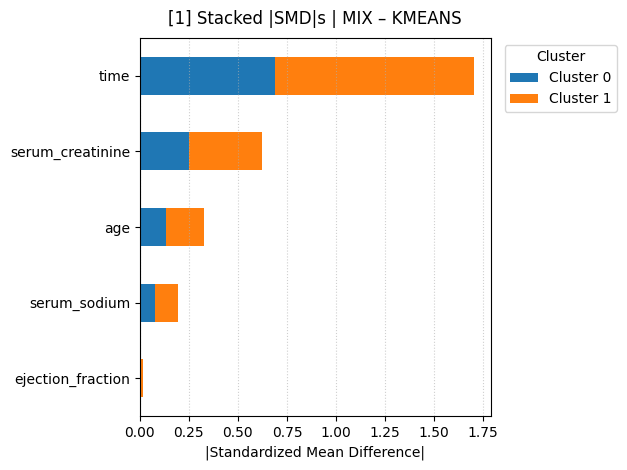

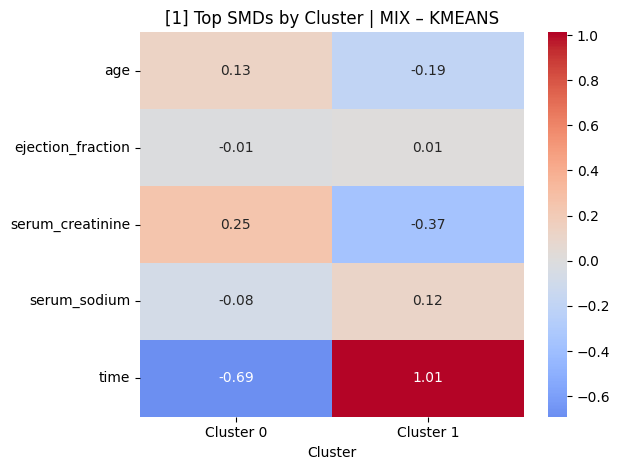


=== [2] MIX – AGGLOMERATIVE ===


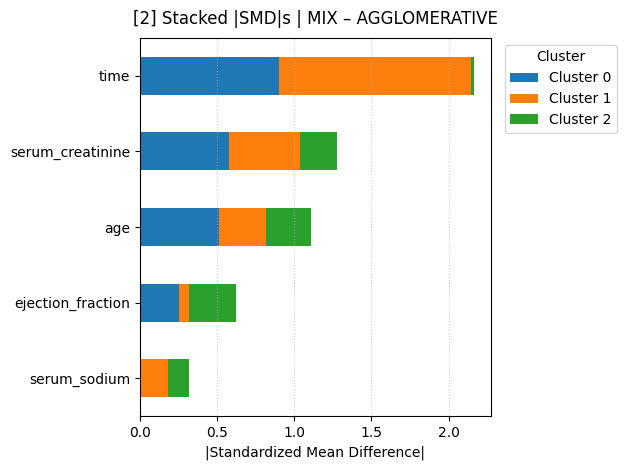

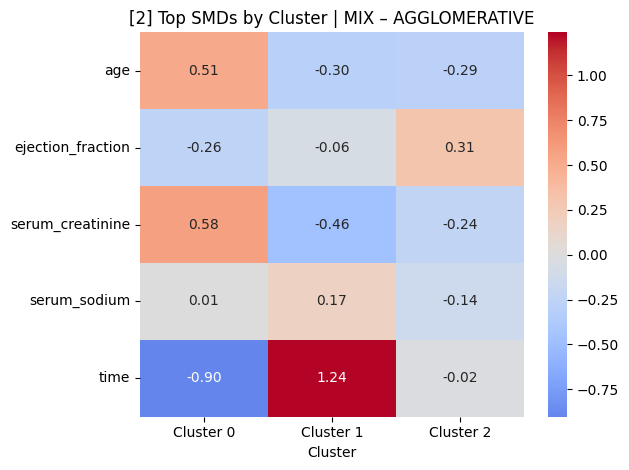


=== [3] UMAP – KMEANS ===


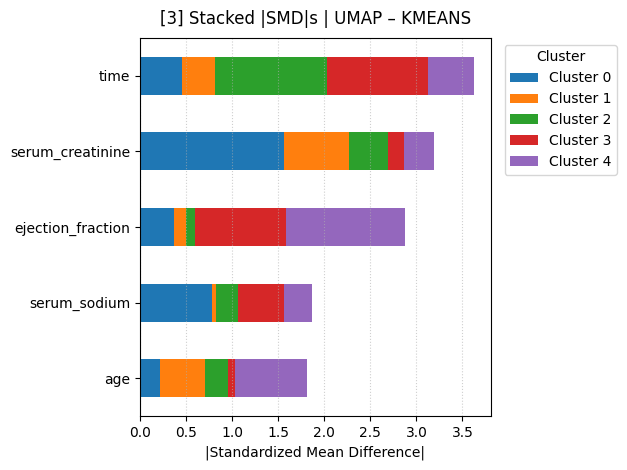

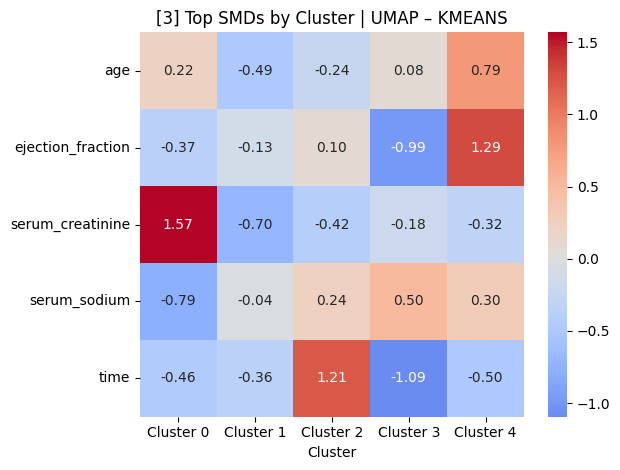

In [ ]:
for rank in range(1, topK + 1):
    entry = ordered_unsupervised[rank - 1]
    algo   = entry["algo"].upper()
    emb    = entry["emb"].upper()
    key    = (rank, emb, algo)
    smd_df = top_smd_tables[key]

    print(f"\n=== [{rank}] {emb} – {algo} ===")
    plot_smd_stacked_bars(smd_df=smd_df, rank=rank, emb=emb, algo=algo)
    plot_smd_heatmap(smd_df=smd_df, rank=rank, emb=emb, algo=algo)

### 3D visualisation of clusters vs DEATH_EVENT

In [ ]:
for rank in range(1, topK + 1):
    entry = ordered_unsupervised[rank - 1]
    algo   = entry["algo"].upper()
    emb    = entry["emb"]
    labels = entry["labels"]
    params = entry["params"]

    plot_clusters_target_3d(
        embeddings_unsupervised[emb],
        labels,
        y,
        title=f"[{rank}] {emb.upper()} – {algo}  params={params} | Clusters vs {TARGET_COL}"
    )

## Baseline Clustering in Original Preprocessed Space
---

In [26]:
db_best_pre = gridsearch_dbscan(X=X_pre)
km_best_pre = gridsearch_kmeans_params(X_pre, ks=range(2, 8), n_inits=(25, 50))
ag_best_pre = gridsearch_agglomerative_params(
    X_pre,
    ks=range(2, 8),
    linkages=("ward", "complete", "average"),
    metrics=("euclidean", "manhattan", "cosine"),
)

params_db_pre = db_best_pre["params"]
params_km_pre = km_best_pre["params"]
params_ag_pre = ag_best_pre["params"]

print("DBSCAN(best on PRE):", params_db_pre)
print("KMeans(best on PRE):", params_km_pre)
print("Agglomerative(best on PRE):", params_ag_pre)

DBSCAN(best on PRE): {'eps': 0.3, 'min_samples': 3}
KMeans(best on PRE): {'n_clusters': 4, 'n_init': 50}
Agglomerative(best on PRE): {'n_clusters': 4, 'linkage': 'ward', 'metric': 'euclidean'}


In [28]:
# Re‑fit the models with the best parameters
db_pre = DBSCAN(**params_db_pre)
km_pre = KMeans(**params_km_pre)
ag_pre = AgglomerativeClustering(
    n_clusters=params_ag_pre["n_clusters"],
    linkage=params_ag_pre["linkage"],
    metric=params_ag_pre.get("metric", "euclidean"),
)

labels_db_pre = db_pre.fit_predict(X_pre)
labels_km_pre = km_pre.fit_predict(X_pre)
labels_ag_pre = ag_pre.fit_predict(X_pre)

scores_db_pre = show_scores("DBSCAN on PRE", X_pre, labels_db_pre, y)
scores_km_pre = show_scores("KMeans on PRE",  X_pre, labels_km_pre, y)
scores_ag_pre = show_scores("Agglomerative on PRE", X_pre, labels_ag_pre, y)

[DBSCAN on PRE] -> clusters=3, noise=2.9%, sil=0.08269899096802112, CH=5.45589071327888, DB=1.9596500146983802, ARI=0.016102190867454486, NMI=0.023963319671802562, V=0.023963319671802562
[KMeans on PRE] -> clusters=4, noise=0.0%, sil=0.24249952410433168, CH=92.67151235488875, DB=1.401133787983193, ARI=0.15532320838995076, NMI=0.1688344188821206, V=0.1688344188821206
[Agglomerative on PRE] -> clusters=4, noise=0.0%, sil=0.227154988661145, CH=86.12278283767782, DB=1.4337194729905218, ARI=0.12747242554528523, NMI=0.1462001150409351, V=0.1462001150409351


## Visualisation of Baseline Clusters in 3D Embeddings


In [30]:
params_db_viz = params_db_pre
params_km_viz = params_km_pre
params_ag_viz = params_ag_pre

for name, X_emb in embeddings_unsupervised.items():
    print(f"\n=== Baseline clusters visualised in {name} ===")
    plot_3d(X3d=X_emb, y=labels_db_pre, algorithm=f"DBSCAN (PRE, {name})", target_name="cluster", data_name=name, show=True)
    plot_3d(X3d=X_emb, y=labels_km_pre, algorithm=f"KMeans (PRE, {name})", target_name="cluster", data_name=name, show=True)
    plot_3d(X3d=X_emb, y=labels_ag_pre, algorithm=f"Agglomerative (PRE, {name})", target_name="cluster", data_name=name, show=True)


=== Baseline clusters visualised in pca ===



=== Baseline clusters visualised in tsne ===



=== Baseline clusters visualised in umap ===



=== Baseline clusters visualised in mix ===


## Supervised embeddings & t-SNE – exploratory clustering

The following section applies clustering to:

- **Supervised UMAP**, **semi-supervised UMAP**, and **XGBoost leaf + UMAP**,
  which are *label-informed* embeddings (they encode information about `DEATH_EVENT`).
- **t-SNE** embeddings, which preserve local neighborhoods but distort global structure.

Because of this, clusters in these spaces **cannot be interpreted** as purely
unsupervised structure in the original clinical feature space. The results are
used mainly for **visualization and exploratory analysis**, not as the main
basis for conclusions.


In [29]:
exploratory_params_km = {
    "umap_supervised":     {"k": 2, "n_init": 10},
    "umap_semisupervised": {"k": 2, "n_init": 10},
    "umap_xgb":            {"k": 3, "n_init": 20},
}

for name, X in embeddings_supervised.items():
    p = exploratory_params_km[name]

    km = KMeans(
        n_clusters=p["k"],
        n_init=p["n_init"],
        random_state=SEED,
    )
    labels = km.fit_predict(X)

    scores = show_scores(f"[EXPLORATORY] KMeans on {name}", X, labels, y)
    append_result(rows, algo="kmeans", embedding=f"{name}_exploratory", labels=labels, scores_in=scores["internal"], scores_ex=scores["external"], params=p)

    fig = plot_3d(X3d=X, y=labels, algorithm=f"[EXPLORATORY] KMeans on {name}", target_name="cluster", data_name=name.upper())
    show(fig)

exploratory_results = []
pd.DataFrame([
    {
        "Embedding": r["emb"],
        "Algorithm": r["algo"].upper(),
        "Clusters": r["metrics"].get("n_clusters"),
        "Silhouette": r["metrics"].get("silhouette"),
        "ARI": r["metrics"].get("ari"),
        "NMI": r["metrics"].get("nmi"),
    }
    for r in exploratory_results
])

[[EXPLORATORY] KMeans on umap_supervised] -> clusters=2, noise=0.0%, sil=0.9414445161819458, CH=32541.92578125, DB=0.08933413556449546, ARI=1.0, NMI=1.0, V=1.0


[[EXPLORATORY] KMeans on umap_semisupervised] -> clusters=2, noise=0.0%, sil=0.8975622057914734, CH=10528.7177734375, DB=0.1538700994095862, ARI=0.9480138828588369, NMI=0.8953682837454585, V=0.8953682837454586


[[EXPLORATORY] KMeans on umap_xgb] -> clusters=3, noise=0.0%, sil=0.7457042336463928, CH=3235.83837890625, DB=0.364139617500923, ARI=0.31704761996980496, NMI=0.3805153133597635, V=0.3805153133597636


""
